# 16 — Calibração de Probabilidades

## Objetivo

Verificar se os scores dos dois candidatos podem ser tratados como probabilidade para decisão por
custo.

Candidatos:

1. `referencia_24h_ids_textual`;
2. `multijanela_core_ids_textual`.

## Desenho temporal

- treino do modelo base: janeiro a março;
- calibração: abril;
- escolha de threshold: maio;
- auditoria final: junho.

## Limites

- `Is_Dont_Go` continua sendo target provisório;
- `p_acao_confirmada` de caminhões usa a taxa observada no treino do notebook 15;
- calibração melhora interpretação probabilística, mas não cria causalidade;
- junho não participa de treino, calibração nem escolha de threshold.

In [1]:
from pathlib import Path
import re
import time
import unicodedata

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, brier_score_loss, f1_score,
    fbeta_score, log_loss, precision_score, recall_score, roc_auc_score,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 250)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
BASE = ROOT / "data" / "raw" / "Base"
TEL_GLOB = str(BASE / "datasets" / "telemetria" / "telemetry_*.parquet")

GAP_S = 900
OBSERVATION_HOURS = 24
HORIZON_HOURS = 8
BUCKET_HOURS = 8
TOP_ALARM_IDS = 200
TOP_TEXT_CONCEPTS = 200
LOOP_TAG = "PE3798"
LOOP_DAY = pd.Timestamp("2025-06-29")
LOOP_ALARM_IDS = (1241582851, 1241582848)
MISSING_START = pd.Timestamp("2025-05-31 00:00:00")
MISSING_END = pd.Timestamp("2025-06-01 00:00:00")
THRESHOLD_GRID = np.round(np.linspace(0.01, 0.99, 197), 3)

economic_base = pd.DataFrame([
    {
        "Tipo": "Caminhao",
        "p_acao_confirmada": 0.655,
        "custo_intervencao_preditiva": 10000.0,
        "custo_manutencao_corretiva": 50000.0,
        "impacto_operacional_hora": 30000.0,
        "horas_parada_corretiva": 4.0,
        "horas_parada_preditiva": 1.0,
    },
    {
        "Tipo": "Escavadeira",
        "p_acao_confirmada": 0.20,
        "custo_intervencao_preditiva": 25000.0,
        "custo_manutencao_corretiva": 150000.0,
        "impacto_operacional_hora": 100000.0,
        "horas_parada_corretiva": 8.0,
        "horas_parada_preditiva": 2.0,
    },
])

con = duckdb.connect()
con.execute("SET threads=4")
con.execute("SET preserve_insertion_order=false")
con.execute(f"CREATE OR REPLACE VIEW tel AS SELECT * FROM read_parquet('{TEL_GLOB}', union_by_name=true)")

def query(sql):
    return con.sql(sql).df()

def normalize_alarm_name(value):
    if pd.isna(value):
        return "SEM_DESCRICAO"
    text = str(value).strip().upper()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"\s*\(L-?\d+\)\s*$", "", text)
    text = re.sub(r"[^A-Z0-9]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text or "SEM_DESCRICAO"

def normalize_tipo(value):
    if pd.isna(value):
        return "Indefinido"
    return "Escavadeira" if "ESCAV" in str(value).upper() else "Caminhao"

print(f"Raiz do projeto: {ROOT}")

Raiz do projeto: /home/f_szekut/projects/vale_correct


## 1. Camada analítica, sequências e amostras

In [2]:
start = time.time()
con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE analytic_events AS
    SELECT
        min(Id_Eventos_Telemetria) AS Id_Eventos_Telemetria_referencia,
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go,
        count(*) AS ids_evento_no_grupo
    FROM tel
    WHERE NOT (
        TAG = '{LOOP_TAG}'
        AND CAST(Data_Evento AS DATE) = DATE '{LOOP_DAY.date()}'
        AND Id_Alarme IN {LOOP_ALARM_IDS}
    )
    GROUP BY
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go
    '''
)

base_audit = query(
    '''
    SELECT count(*) AS registros_analiticos,
           sum(ids_evento_no_grupo - 1) AS duplicatas_retiradas,
           sum(Is_Dont_Go) AS linhas_dont_go
    FROM analytic_events
    '''
)
display(base_audit)

,registros_analiticos,duplicatas_retiradas,linhas_dont_go
0,35608094,265564.0,19941.0


In [3]:
def build_sequences():
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE alarm_sequences AS
        WITH ordered AS (
            SELECT *,
                   lag(Data_Evento) OVER (
                       PARTITION BY TAG, Id_Alarme ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                   ) AS evento_anterior
            FROM analytic_events
        ), flagged AS (
            SELECT *,
                   CASE
                       WHEN evento_anterior IS NULL THEN 1
                       WHEN date_diff('millisecond', evento_anterior, Data_Evento) > {GAP_S * 1000} THEN 1
                       ELSE 0
                   END AS nova_sequencia
            FROM ordered
        ), numbered AS (
            SELECT *,
                   sum(nova_sequencia) OVER (
                       PARTITION BY TAG, Id_Alarme
                       ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                       ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
                   ) AS numero_sequencia
            FROM flagged
        )
        SELECT
            TAG, any_value(Tag_Frota) AS Tag_Frota, any_value(Tipo) AS Tipo,
            Id_Alarme, any_value(Alarme) AS Alarme,
            numero_sequencia,
            min(Data_Evento) AS inicio,
            max(Data_Evento) AS fim,
            time_bucket(INTERVAL '8 hours', min(Data_Evento)) AS bin_start,
            date_diff('millisecond', min(Data_Evento), max(Data_Evento)) AS duracao_ms,
            count(*) AS registros_analiticos,
            sum(ids_evento_no_grupo) AS registros_brutos_representados,
            max(Is_Dont_Go) AS is_dont_go,
            max(CASE WHEN Id_Criticidade = 1 THEN 1 ELSE 0 END) AS possui_critico,
            max(CASE WHEN Classe = 'Activate' THEN 1 ELSE 0 END) AS possui_activate,
            max(CASE WHEN Classe = 'Inactive' THEN 1 ELSE 0 END) AS possui_inactive,
            max(CASE WHEN Classe IS NULL THEN 1 ELSE 0 END) AS possui_classe_nula
        FROM numbered
        GROUP BY TAG, Id_Alarme, numero_sequencia
        '''
    )
    return query(
        '''
        SELECT count(*) AS sequencias,
               sum(is_dont_go) AS sequencias_dont_go,
               avg(registros_analiticos) AS registros_por_sequencia_media,
               max(registros_analiticos) AS maior_sequencia
        FROM alarm_sequences
        '''
    )

def create_catalog():
    catalog = query(
        '''
        SELECT Id_Alarme, any_value(Alarme) AS Alarme, count(*) AS sequencias
        FROM alarm_sequences
        GROUP BY 1
        ORDER BY sequencias DESC
        '''
    )
    catalog["conceito_textual"] = catalog["Alarme"].map(normalize_alarm_name)
    con.register("alarm_concepts", catalog[["Id_Alarme", "conceito_textual"]])
    return catalog

def build_sample_grid():
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE sample_grid AS
        WITH tags AS (
            SELECT DISTINCT TAG FROM analytic_events
        ), prediction_bins AS (
            SELECT * FROM generate_series(
                TIMESTAMP '2025-01-01 00:00:00' + INTERVAL '{OBSERVATION_HOURS} hours',
                TIMESTAMP '2025-07-01 00:00:00' - INTERVAL '{HORIZON_HOURS} hours',
                INTERVAL '8 hours'
            ) AS t(prediction_time)
        )
        SELECT
            row_number() OVER () AS sample_id,
            tags.TAG,
            prediction_time - INTERVAL '{OBSERVATION_HOURS} hours' AS feature_start,
            prediction_time,
            prediction_time + INTERVAL '{HORIZON_HOURS} hours' AS target_end
        FROM tags CROSS JOIN prediction_bins
        WHERE prediction_time - INTERVAL '{OBSERVATION_HOURS} hours' >= TIMESTAMP '2025-01-01 00:00:00'
        '''
    )

def build_sequence_bins():
    con.execute(
        '''
        CREATE OR REPLACE TEMP TABLE sequence_bins AS
        SELECT
            TAG, bin_start,
            count(*) AS sequencias_total,
            count(DISTINCT Id_Alarme) AS alarmes_distintos,
            sum(registros_analiticos) AS registros_analiticos,
            sum(registros_brutos_representados) AS registros_brutos_representados,
            sum(duracao_ms) AS duracao_soma_ms,
            max(duracao_ms) AS duracao_max_ms,
            max(registros_analiticos) AS maior_sequencia_registros,
            sum(possui_critico) AS sequencias_com_critico,
            sum(possui_activate) AS sequencias_com_activate,
            sum(possui_inactive) AS sequencias_com_inactive,
            sum(possui_classe_nula) AS sequencias_com_classe_nula,
            sum(is_dont_go) AS episodios_dont_go
        FROM alarm_sequences
        GROUP BY 1, 2
        '''
    )

In [4]:
def build_samples():
    samples = query(
        f'''
        WITH feature_agg AS (
            SELECT
                g.sample_id,
                coalesce(sum(b.sequencias_total), 0) AS sequencias_total,
                coalesce(sum(b.alarmes_distintos), 0) AS alarmes_distintos,
                coalesce(sum(b.registros_analiticos), 0) AS registros_analiticos,
                coalesce(sum(b.registros_brutos_representados), 0) AS registros_brutos_representados,
                CASE
                    WHEN coalesce(sum(b.sequencias_total), 0) > 0
                    THEN coalesce(sum(b.duracao_soma_ms), 0) / sum(b.sequencias_total)
                    ELSE 0
                END AS duracao_media_ms,
                coalesce(max(b.duracao_max_ms), 0) AS duracao_max_ms,
                coalesce(max(b.maior_sequencia_registros), 0) AS maior_sequencia_registros,
                coalesce(sum(b.sequencias_com_critico), 0) AS sequencias_com_critico,
                coalesce(sum(b.sequencias_com_activate), 0) AS sequencias_com_activate,
                coalesce(sum(b.sequencias_com_inactive), 0) AS sequencias_com_inactive,
                coalesce(sum(b.sequencias_com_classe_nula), 0) AS sequencias_com_classe_nula
            FROM sample_grid g
            LEFT JOIN sequence_bins b
              ON b.TAG = g.TAG
             AND b.bin_start >= g.feature_start
             AND b.bin_start < g.prediction_time
            GROUP BY 1
        ), target_agg AS (
            SELECT
                g.sample_id,
                coalesce(sum(b.episodios_dont_go), 0) AS episodios_dont_go_target
            FROM sample_grid g
            LEFT JOIN sequence_bins b
              ON b.TAG = g.TAG
             AND b.bin_start >= g.prediction_time
             AND b.bin_start < g.target_end
            GROUP BY 1
        )
        SELECT
            g.sample_id, g.TAG, g.feature_start, g.prediction_time, g.target_end,
            f.* EXCLUDE(sample_id),
            y.episodios_dont_go_target,
            CASE WHEN y.episodios_dont_go_target > 0 THEN 1 ELSE 0 END AS target,
            CASE
                WHEN g.feature_start < TIMESTAMP '{MISSING_END}'
                 AND g.target_end > TIMESTAMP '{MISSING_START}'
                THEN 0 ELSE 1
            END AS amostra_valida
        FROM sample_grid g
        JOIN feature_agg f USING(sample_id)
        JOIN target_agg y USING(sample_id)
        ORDER BY g.prediction_time, g.TAG
        '''
    )
    samples = samples[samples["amostra_valida"] == 1].copy()
    tag_profile = query(
        '''
        SELECT TAG, any_value(Tipo) AS Tipo, any_value(Tag_Frota) AS Tag_Frota
        FROM analytic_events
        GROUP BY 1
        '''
    )
    samples = samples.merge(tag_profile, how="left", on="TAG")
    samples["Tipo"] = samples["Tipo"].replace({"Caminhão": "Caminhao"})
    samples = samples.assign(periodo=np.select(
        [
            samples["prediction_time"] < pd.Timestamp("2025-04-01"),
            samples["prediction_time"] < pd.Timestamp("2025-05-01"),
            samples["prediction_time"] < pd.Timestamp("2025-05-31"),
            samples["prediction_time"] >= pd.Timestamp("2025-06-01"),
        ],
        ["treino_base", "calibracao", "validacao", "teste"],
        default="fora_do_split",
    ))
    return samples[samples["periodo"].isin(["treino_base", "calibracao", "validacao", "teste"])].copy()

def add_base_features(samples):
    samples = pd.concat([
        samples,
        pd.DataFrame({
            "feature_has_events": (samples["sequencias_total"] > 0).astype("int8"),
            "prediction_hour_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.hour / 24),
            "prediction_hour_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.hour / 24),
            "prediction_dow_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
            "prediction_dow_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
        }, index=samples.index)
    ], axis=1).copy()
    return samples, [
        "sequencias_total", "alarmes_distintos", "registros_analiticos",
        "registros_brutos_representados", "duracao_media_ms", "duracao_max_ms",
        "maior_sequencia_registros", "sequencias_com_critico",
        "sequencias_com_activate", "sequencias_com_inactive",
        "sequencias_com_classe_nula", "feature_has_events",
        "prediction_hour_sin", "prediction_hour_cos",
        "prediction_dow_sin", "prediction_dow_cos",
    ]

def sql_literal(value):
    return "'" + str(value).replace("'", "''") + "'"

In [5]:
def add_aggregate_id_features(samples):
    top_ids = query(
        f'''
        SELECT Id_Alarme, count(*) AS sequencias
        FROM alarm_sequences
        WHERE inicio < TIMESTAMP '2025-04-01 00:00:00'
        GROUP BY 1
        ORDER BY sequencias DESC, Id_Alarme
        LIMIT {TOP_ALARM_IDS}
        '''
    )["Id_Alarme"].astype(int).tolist()
    expr = ",\n".join(
        f"sum(CASE WHEN Id_Alarme = {alarm_id} THEN 1 ELSE 0 END) AS alarm_{alarm_id}"
        for alarm_id in top_ids
    )
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE alarm_bin_features AS
        SELECT TAG, bin_start, {expr}
        FROM alarm_sequences
        GROUP BY 1, 2
        '''
    )
    sum_expr = ", ".join(
        f"coalesce(sum(b.alarm_{alarm_id}), 0) AS alarm_{alarm_id}" for alarm_id in top_ids
    )
    wide = query(
        f'''
        SELECT g.sample_id, {sum_expr}
        FROM sample_grid g
        LEFT JOIN alarm_bin_features b
          ON b.TAG = g.TAG
         AND b.bin_start >= g.feature_start
         AND b.bin_start < g.prediction_time
        GROUP BY 1
        '''
    )
    features = [f"alarm_{alarm_id}" for alarm_id in top_ids]
    samples = samples.merge(wide, how="left", on="sample_id")
    samples[features] = samples[features].fillna(0).astype("int32")
    return samples, features

def add_aggregate_text_features(samples):
    top = query(
        f'''
        SELECT c.conceito_textual AS valor, count(*) AS sequencias
        FROM alarm_sequences s
        JOIN alarm_concepts c USING(Id_Alarme)
        WHERE s.inicio < TIMESTAMP '2025-04-01 00:00:00'
        GROUP BY 1
        ORDER BY sequencias DESC, valor
        LIMIT {TOP_TEXT_CONCEPTS}
        '''
    )
    values = top["valor"].tolist()
    name_map = {value: f"textconcept_{i:03d}" for i, value in enumerate(values)}
    expr = ",\n".join(
        f"sum(CASE WHEN c.conceito_textual = {sql_literal(value)} THEN 1 ELSE 0 END) AS {name_map[value]}"
        for value in values
    )
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE text_bin_features AS
        SELECT s.TAG, s.bin_start, {expr}
        FROM alarm_sequences s
        LEFT JOIN alarm_concepts c USING(Id_Alarme)
        GROUP BY 1, 2
        '''
    )
    sum_expr = ", ".join(
        f"coalesce(sum(b.{name_map[value]}), 0) AS {name_map[value]}" for value in values
    )
    wide = query(
        f'''
        SELECT g.sample_id, {sum_expr}
        FROM sample_grid g
        LEFT JOIN text_bin_features b
          ON b.TAG = g.TAG
         AND b.bin_start >= g.feature_start
         AND b.bin_start < g.prediction_time
        GROUP BY 1
        '''
    )
    features = [name_map[value] for value in values]
    samples = samples.merge(wide, how="left", on="sample_id")
    samples[features] = samples[features].fillna(0).astype("int32")
    return samples, features

def add_core_bucket_features(samples):
    core_cols = [
        "sequencias_total", "alarmes_distintos", "registros_analiticos",
        "registros_brutos_representados", "duracao_soma_ms", "duracao_max_ms",
        "maior_sequencia_registros", "sequencias_com_critico",
        "sequencias_com_activate", "sequencias_com_inactive", "sequencias_com_classe_nula",
    ]
    select_parts = []
    for bucket_idx in range(3):
        start_h = bucket_idx * BUCKET_HOURS
        end_h = (bucket_idx + 1) * BUCKET_HOURS
        suffix = f"b{bucket_idx}_{start_h}_{end_h}h"
        for col in core_cols:
            select_parts.append(
                f"coalesce(sum(CASE WHEN b.bin_start >= g.prediction_time - INTERVAL '{end_h} hours' "
                f"AND b.bin_start < g.prediction_time - INTERVAL '{start_h} hours' "
                f"THEN b.{col} ELSE 0 END), 0) AS {col}_{suffix}"
            )
    wide = query(
        f'''
        SELECT g.sample_id,
               {", ".join(select_parts)}
        FROM sample_grid g
        LEFT JOIN sequence_bins b
          ON b.TAG = g.TAG
         AND b.bin_start >= g.feature_start
         AND b.bin_start < g.prediction_time
        GROUP BY 1
        '''
    )
    features = [c for c in wide.columns if c != "sample_id"]
    samples = samples.merge(wide, how="left", on="sample_id")
    samples[features] = samples[features].fillna(0).astype("float32")
    derived_data = {}
    derived = []
    for base in ["sequencias_total", "alarmes_distintos", "registros_analiticos", "sequencias_com_critico"]:
        recent = f"{base}_b0_0_8h"
        middle = f"{base}_b1_8_16h"
        old = f"{base}_b2_16_24h"
        delta_recent_old = f"{base}_delta_recent_old"
        ratio_recent_total = f"{base}_ratio_recent_total"
        derived_data[delta_recent_old] = samples[recent] - samples[old]
        derived_data[ratio_recent_total] = samples[recent] / (samples[recent] + samples[middle] + samples[old] + 1)
        derived.extend([delta_recent_old, ratio_recent_total])
    samples = pd.concat([samples, pd.DataFrame(derived_data, index=samples.index)], axis=1).copy()
    return samples, features + derived

In [6]:
seq_audit = build_sequences()
catalog = create_catalog()
build_sample_grid()
build_sequence_bins()
samples = build_samples()
samples, base_features = add_base_features(samples)
samples, aggregate_id_features = add_aggregate_id_features(samples)
samples, aggregate_text_features = add_aggregate_text_features(samples)
samples, core_bucket_features = add_core_bucket_features(samples)
print(f"Preparação total: {time.time() - start:.1f}s")
display(seq_audit)
display(samples.groupby(["periodo", "Tipo"], dropna=False).agg(
    amostras=("target", "size"),
    positivas=("target", "sum"),
    prevalencia=("target", "mean"),
).reset_index())

Preparação total: 92.2s


,sequencias,sequencias_dont_go,registros_por_sequencia_media,maior_sequencia
0,979994,7572.0,36.335012,32721


,periodo,Tipo,amostras,positivas,prevalencia
0,calibracao,Caminhao,2700,363,0.134444
1,calibracao,Escavadeira,450,1,0.002222
2,teste,Caminhao,2610,283,0.108429
3,teste,Escavadeira,435,2,0.004598
4,treino_base,Caminhao,8010,1532,0.191261
5,treino_base,Escavadeira,1335,14,0.010487
6,validacao,Caminhao,2700,280,0.103704
7,validacao,Escavadeira,450,7,0.015556


## 2. Modelos base e calibradores

In [7]:
def fit_raw_predictions(feature_columns, cenario):
    train = samples[samples["periodo"] == "treino_base"]
    cal = samples[samples["periodo"] == "calibracao"]
    val = samples[samples["periodo"] == "validacao"]
    test = samples[samples["periodo"] == "teste"]
    model = RandomForestClassifier(
        n_estimators=300,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(train[feature_columns].astype("float32"), train["target"].astype("int8"))
    frames = []
    for periodo, part in [("calibracao", cal), ("validacao", val), ("teste", test)]:
        prob = model.predict_proba(part[feature_columns].astype("float32"))[:, 1]
        pred = part[["sample_id", "TAG", "Tipo", "Tag_Frota", "prediction_time", "target"]].copy()
        pred["cenario"] = cenario
        pred["periodo"] = periodo
        pred["prob_raw"] = prob
        frames.append(pred)
    return pd.concat(frames, ignore_index=True)

feature_sets = {
    "referencia_24h_ids_textual": base_features + aggregate_id_features + aggregate_text_features,
    "multijanela_core_ids_textual": core_bucket_features + aggregate_id_features + aggregate_text_features,
}

raw_predictions = []
for cenario, cols in feature_sets.items():
    print(f"Treinando {cenario}: {len(cols)} features")
    raw_predictions.append(fit_raw_predictions(cols, cenario))
raw_predictions = pd.concat(raw_predictions, ignore_index=True)
display(raw_predictions.groupby(["cenario", "periodo"]).agg(
    amostras=("target", "size"),
    positivas=("target", "sum"),
    prob_media=("prob_raw", "mean"),
).reset_index())

Treinando referencia_24h_ids_textual: 416 features


Treinando multijanela_core_ids_textual: 441 features


,cenario,periodo,amostras,positivas,prob_media
0,multijanela_core_ids_textual,calibracao,3150,364,0.166319
1,multijanela_core_ids_textual,teste,3045,285,0.157310
2,multijanela_core_ids_textual,validacao,3150,287,0.154344
3,referencia_24h_ids_textual,calibracao,3150,364,0.172102
4,referencia_24h_ids_textual,teste,3045,285,0.166532
5,referencia_24h_ids_textual,validacao,3150,287,0.160923


In [8]:
def fit_calibrators(df):
    cal = df[df["periodo"] == "calibracao"].copy()
    x = cal["prob_raw"].to_numpy().reshape(-1, 1)
    y = cal["target"].astype("int8").to_numpy()
    sigmoid = LogisticRegression(solver="lbfgs")
    sigmoid.fit(x, y)
    isotonic = IsotonicRegression(out_of_bounds="clip")
    isotonic.fit(cal["prob_raw"].to_numpy(), y)
    return sigmoid, isotonic

calibrated_parts = []
for cenario, part in raw_predictions.groupby("cenario"):
    sigmoid, isotonic = fit_calibrators(part)
    out = part.copy()
    out["prob_raw_calibrated"] = out["prob_raw"]
    out["prob_sigmoid"] = sigmoid.predict_proba(out["prob_raw"].to_numpy().reshape(-1, 1))[:, 1]
    out["prob_isotonic"] = isotonic.predict(out["prob_raw"].to_numpy())
    calibrated_parts.append(out)
predictions = pd.concat(calibrated_parts, ignore_index=True)

long_predictions = predictions.melt(
    id_vars=["sample_id", "TAG", "Tipo", "Tag_Frota", "prediction_time", "target", "cenario", "periodo"],
    value_vars=["prob_raw_calibrated", "prob_sigmoid", "prob_isotonic"],
    var_name="calibracao",
    value_name="probabilidade",
)
long_predictions["calibracao"] = long_predictions["calibracao"].str.replace("prob_", "", regex=False)
display(long_predictions.groupby(["cenario", "periodo", "calibracao"]).agg(
    amostras=("target", "size"),
    positivas=("target", "sum"),
    prob_media=("probabilidade", "mean"),
).reset_index())

,cenario,periodo,calibracao,amostras,positivas,prob_media
0,multijanela_core_ids_textual,calibracao,isotonic,3150,364,0.115556
1,multijanela_core_ids_textual,calibracao,raw_calibrated,3150,364,0.166319
2,multijanela_core_ids_textual,calibracao,sigmoid,3150,364,0.115551
3,multijanela_core_ids_textual,teste,isotonic,3045,285,0.107093
4,multijanela_core_ids_textual,teste,raw_calibrated,3045,285,0.157310
5,multijanela_core_ids_textual,teste,sigmoid,3045,285,0.108341
6,multijanela_core_ids_textual,validacao,isotonic,3150,287,0.105463
7,multijanela_core_ids_textual,validacao,raw_calibrated,3150,287,0.154344
8,multijanela_core_ids_textual,validacao,sigmoid,3150,287,0.106155
9,referencia_24h_ids_textual,calibracao,isotonic,3150,364,0.115556


## 3. Métricas de calibração

In [9]:
def expected_calibration_error(y_true, prob, bins=10):
    df = pd.DataFrame({"y": y_true, "p": prob})
    df["bin"] = pd.cut(df["p"], np.linspace(0, 1, bins + 1), include_lowest=True)
    grouped = df.groupby("bin", observed=False).agg(n=("y", "size"), taxa=("y", "mean"), prob_media=("p", "mean")).reset_index()
    grouped = grouped[grouped["n"] > 0].copy()
    return float((grouped["n"] / grouped["n"].sum() * (grouped["taxa"] - grouped["prob_media"]).abs()).sum())

calibration_rows = []
for (cenario, periodo, calibracao), part in long_predictions.groupby(["cenario", "periodo", "calibracao"]):
    y = part["target"].astype("int8")
    p = part["probabilidade"].clip(1e-6, 1 - 1e-6)
    calibration_rows.append({
        "cenario": cenario,
        "periodo": periodo,
        "calibracao": calibracao,
        "amostras": len(part),
        "positivas": int(y.sum()),
        "prevalencia": y.mean(),
        "prob_media": p.mean(),
        "brier": brier_score_loss(y, p),
        "log_loss": log_loss(y, p),
        "ece_10": expected_calibration_error(y, p, bins=10),
        "pr_auc": average_precision_score(y, p),
        "roc_auc": roc_auc_score(y, p),
    })
calibration_metrics = pd.DataFrame(calibration_rows)
display(calibration_metrics.sort_values(["periodo", "cenario", "brier"]))

test_calibration = calibration_metrics[calibration_metrics["periodo"] == "teste"].copy()
display(test_calibration.sort_values(["cenario", "brier"]))

,cenario,periodo,calibracao,amostras,positivas,prevalencia,prob_media,brier,log_loss,ece_10,pr_auc,roc_auc
0,multijanela_core_ids_textual,calibracao,isotonic,3150,364,0.115556,0.115556,0.083644,0.282157,3.587302e-08,0.382211,0.810337
2,multijanela_core_ids_textual,calibracao,sigmoid,3150,364,0.115556,0.115551,0.085640,0.294425,1.585377e-02,0.387925,0.805019
1,multijanela_core_ids_textual,calibracao,raw_calibrated,3150,364,0.115556,0.166319,0.088896,0.300624,5.080384e-02,0.387925,0.805019
9,referencia_24h_ids_textual,calibracao,isotonic,3150,364,0.115556,0.115556,0.084578,0.282833,1.523810e-07,0.367013,0.812821
11,referencia_24h_ids_textual,calibracao,sigmoid,3150,364,0.115556,0.115567,0.086532,0.295500,1.769126e-02,0.371987,0.806217
10,referencia_24h_ids_textual,calibracao,raw_calibrated,3150,364,0.115556,0.172102,0.090822,0.303803,5.654623e-02,0.371987,0.806217
3,multijanela_core_ids_textual,teste,isotonic,3045,285,0.093596,0.107093,0.071458,0.251841,1.349736e-02,0.338050,0.823858
5,multijanela_core_ids_textual,teste,sigmoid,3045,285,0.093596,0.108341,0.072184,0.255504,2.351658e-02,0.352108,0.825819
4,multijanela_core_ids_textual,teste,raw_calibrated,3045,285,0.093596,0.157310,0.077241,0.271009,6.371401e-02,0.352108,0.825819
14,referencia_24h_ids_textual,teste,sigmoid,3045,285,0.093596,0.110222,0.073178,0.257710,1.735276e-02,0.333342,0.818865


,cenario,periodo,calibracao,amostras,positivas,prevalencia,prob_media,brier,log_loss,ece_10,pr_auc,roc_auc
3,multijanela_core_ids_textual,teste,isotonic,3045,285,0.093596,0.107093,0.071458,0.251841,0.013497,0.338050,0.823858
5,multijanela_core_ids_textual,teste,sigmoid,3045,285,0.093596,0.108341,0.072184,0.255504,0.023517,0.352108,0.825819
4,multijanela_core_ids_textual,teste,raw_calibrated,3045,285,0.093596,0.157310,0.077241,0.271009,0.063714,0.352108,0.825819
14,referencia_24h_ids_textual,teste,sigmoid,3045,285,0.093596,0.110222,0.073178,0.257710,0.017353,0.333342,0.818865
12,referencia_24h_ids_textual,teste,isotonic,3045,285,0.093596,0.111035,0.073316,0.256640,0.017438,0.309862,0.816653
13,referencia_24h_ids_textual,teste,raw_calibrated,3045,285,0.093596,0.166532,0.080472,0.278287,0.072936,0.333342,0.818865


,bin,amostras,taxa_observada,prob_media,cenario,calibracao
0,"(-0.001, 0.1]",1773,0.024817,0.034788,multijanela_core_ids_textual,isotonic
1,"(0.1, 0.2]",968,0.129132,0.143710,multijanela_core_ids_textual,isotonic
2,"(0.2, 0.3]",110,0.290909,0.296296,multijanela_core_ids_textual,isotonic
3,"(0.3, 0.4]",31,0.290323,0.316068,multijanela_core_ids_textual,isotonic
4,"(0.4, 0.5]",100,0.360000,0.432850,multijanela_core_ids_textual,isotonic
5,"(0.5, 0.6]",0,NaN,NaN,multijanela_core_ids_textual,isotonic
6,"(0.6, 0.7]",63,0.619048,0.629101,multijanela_core_ids_textual,isotonic
7,"(0.7, 0.8]",0,NaN,NaN,multijanela_core_ids_textual,isotonic
8,"(0.8, 0.9]",0,NaN,NaN,multijanela_core_ids_textual,isotonic
9,"(0.9, 1.0]",0,NaN,NaN,multijanela_core_ids_textual,isotonic


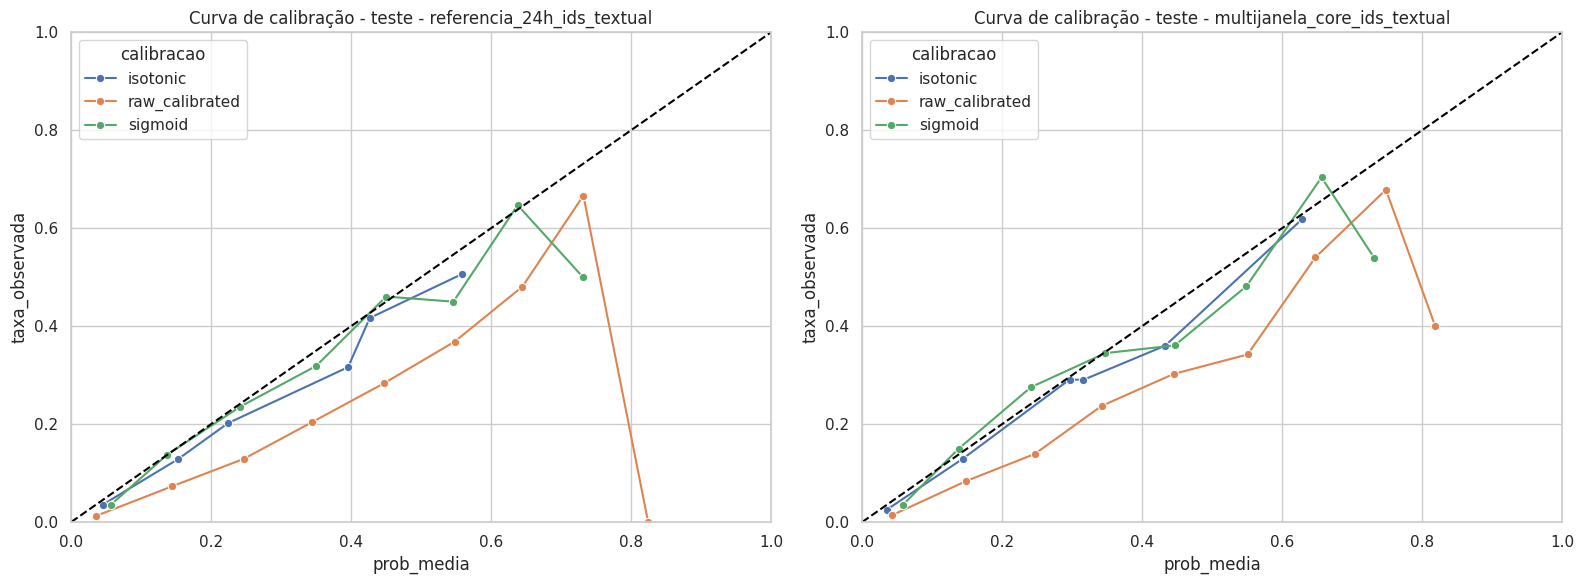

In [10]:
reliability = []
for (cenario, periodo, calibracao), part in long_predictions.groupby(["cenario", "periodo", "calibracao"]):
    if periodo != "teste":
        continue
    tmp = part.copy()
    tmp["bin"] = pd.cut(tmp["probabilidade"], np.linspace(0, 1, 11), include_lowest=True)
    rel = tmp.groupby("bin", observed=False).agg(
        amostras=("target", "size"),
        taxa_observada=("target", "mean"),
        prob_media=("probabilidade", "mean"),
    ).reset_index()
    rel["cenario"] = cenario
    rel["calibracao"] = calibracao
    reliability.append(rel)
reliability = pd.concat(reliability, ignore_index=True)
display(reliability)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, cenario in zip(axes, feature_sets.keys()):
    part = reliability[(reliability["cenario"] == cenario) & (reliability["amostras"] > 0)]
    sns.lineplot(data=part, x="prob_media", y="taxa_observada", hue="calibracao", marker="o", ax=ax)
    ax.plot([0, 1], [0, 1], color="black", linestyle="--")
    ax.set(title=f"Curva de calibração - teste - {cenario}", xlim=(0, 1), ylim=(0, 1))
plt.tight_layout()
plt.show()

## 4. Threshold econômico após calibração

In [11]:
def economic_value_rows(pred_df, threshold):
    scored = pred_df.copy()
    scored["predito"] = (scored["probabilidade"] >= threshold).astype("int8")
    scored["erro"] = np.select(
        [
            (scored["target"] == 1) & (scored["predito"] == 1),
            (scored["target"] == 0) & (scored["predito"] == 1),
            (scored["target"] == 1) & (scored["predito"] == 0),
            (scored["target"] == 0) & (scored["predito"] == 0),
        ],
        ["TP", "FP", "FN", "TN"],
        default="indefinido",
    )
    scored["tipo_economico"] = scored["Tipo"].map(normalize_tipo)
    scored = scored.merge(economic_base.rename(columns={"Tipo": "tipo_economico"}), how="left", on="tipo_economico")
    no_action_cost = scored["p_acao_confirmada"] * (
        scored["custo_manutencao_corretiva"]
        + scored["impacto_operacional_hora"] * scored["horas_parada_corretiva"]
    )
    tp_action_cost = scored["custo_intervencao_preditiva"] + scored["p_acao_confirmada"] * (
        scored["impacto_operacional_hora"] * scored["horas_parada_preditiva"]
    )
    fp_action_cost = scored["custo_intervencao_preditiva"] + (
        scored["impacto_operacional_hora"] * scored["horas_parada_preditiva"]
    )
    scored["valor_incremental"] = np.select(
        [
            scored["erro"] == "TP",
            scored["erro"] == "FP",
            scored["erro"] == "FN",
            scored["erro"] == "TN",
        ],
        [
            no_action_cost - tp_action_cost,
            -fp_action_cost,
            0.0,
            0.0,
        ],
        default=np.nan,
    )
    return scored

def metric_at_threshold(df, threshold):
    y = df["target"].astype("int8")
    p = df["probabilidade"].to_numpy()
    pred = (p >= threshold).astype("int8")
    scored = economic_value_rows(df, threshold)
    return {
        "threshold": threshold,
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f2": fbeta_score(y, pred, beta=2, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "TP": int(((y == 1) & (pred == 1)).sum()),
        "FP": int(((y == 0) & (pred == 1)).sum()),
        "FN": int(((y == 1) & (pred == 0)).sum()),
        "TN": int(((y == 0) & (pred == 0)).sum()),
        "predicoes_positivas": int(pred.sum()),
        "valor_incremental": scored["valor_incremental"].sum(),
    }

threshold_rows = []
for (cenario, periodo, calibracao), part in long_predictions.groupby(["cenario", "periodo", "calibracao"]):
    if periodo not in ["validacao", "teste"]:
        continue
    for threshold in THRESHOLD_GRID:
        row = metric_at_threshold(part, threshold)
        row.update({"cenario": cenario, "periodo": periodo, "calibracao": calibracao})
        threshold_rows.append(row)
threshold_metrics = pd.DataFrame(threshold_rows)

choices = (
    threshold_metrics[threshold_metrics["periodo"] == "validacao"]
    .sort_values(["cenario", "calibracao", "valor_incremental", "threshold"], ascending=[True, True, False, False])
    .groupby(["cenario", "calibracao"])
    .head(1)
    [["cenario", "calibracao", "threshold", "valor_incremental"]]
    .rename(columns={"threshold": "threshold_validacao", "valor_incremental": "valor_validacao"})
)

test_economic = threshold_metrics[threshold_metrics["periodo"] == "teste"].merge(
    choices,
    left_on=["cenario", "calibracao", "threshold"],
    right_on=["cenario", "calibracao", "threshold_validacao"],
    how="inner",
)
display(choices.sort_values(["cenario", "valor_validacao"], ascending=[True, False]))
display(test_economic.sort_values("valor_incremental", ascending=False)[[
    "cenario", "calibracao", "threshold", "valor_incremental", "precision", "recall", "f2",
    "TP", "FP", "FN", "TN", "predicoes_positivas"
]])

,cenario,calibracao,threshold_validacao,valor_validacao
1045,multijanela_core_ids_textual,sigmoid,0.310,2702800.0
875,multijanela_core_ids_textual,raw_calibrated,0.445,2664500.0
652,multijanela_core_ids_textual,isotonic,0.315,2504500.0
2246,referencia_24h_ids_textual,sigmoid,0.405,1736900.0
2067,referencia_24h_ids_textual,raw_calibrated,0.495,1712200.0
1856,referencia_24h_ids_textual,isotonic,0.425,1645000.0


,cenario,calibracao,threshold,valor_incremental,precision,recall,f2,TP,FP,FN,TN,predicoes_positivas
2,multijanela_core_ids_textual,sigmoid,0.310,2454300.0,0.441341,0.277193,0.299469,79,100,206,2660,179
0,multijanela_core_ids_textual,isotonic,0.315,2379400.0,0.431579,0.287719,0.308271,82,108,203,2652,190
1,multijanela_core_ids_textual,raw_calibrated,0.445,2377700.0,0.433155,0.284211,0.305200,81,106,204,2654,187
5,referencia_24h_ids_textual,sigmoid,0.405,2298600.0,0.487395,0.203509,0.230342,58,61,227,2699,119
4,referencia_24h_ids_textual,raw_calibrated,0.495,1839000.0,0.419162,0.245614,0.267789,70,97,215,2663,167
3,referencia_24h_ids_textual,isotonic,0.425,1798200.0,0.484211,0.161404,0.186235,46,49,239,2711,95


## 5. Leitura auditada

In [12]:
best_brier = (
    test_calibration.sort_values(["cenario", "brier"])
    .groupby("cenario")
    .head(1)
    [["cenario", "calibracao", "brier", "ece_10", "prob_media", "prevalencia", "pr_auc"]]
)
best_value = test_economic.sort_values("valor_incremental", ascending=False).head(10)
print("Melhor calibração por Brier no teste:")
display(best_brier)
print("Melhores escolhas econômicas no teste, usando threshold escolhido na validação:")
display(best_value[[
    "cenario", "calibracao", "threshold", "valor_incremental", "precision", "recall", "TP", "FP", "FN"
]])

Melhor calibração por Brier no teste:


,cenario,calibracao,brier,ece_10,prob_media,prevalencia,pr_auc
3,multijanela_core_ids_textual,isotonic,0.071458,0.013497,0.107093,0.093596,0.338050
14,referencia_24h_ids_textual,sigmoid,0.073178,0.017353,0.110222,0.093596,0.333342


Melhores escolhas econômicas no teste, usando threshold escolhido na validação:


,cenario,calibracao,threshold,valor_incremental,precision,recall,TP,FP,FN
2,multijanela_core_ids_textual,sigmoid,0.310,2454300.0,0.441341,0.277193,79,100,206
0,multijanela_core_ids_textual,isotonic,0.315,2379400.0,0.431579,0.287719,82,108,203
1,multijanela_core_ids_textual,raw_calibrated,0.445,2377700.0,0.433155,0.284211,81,106,204
5,referencia_24h_ids_textual,sigmoid,0.405,2298600.0,0.487395,0.203509,58,61,227
4,referencia_24h_ids_textual,raw_calibrated,0.495,1839000.0,0.419162,0.245614,70,97,215
3,referencia_24h_ids_textual,isotonic,0.425,1798200.0,0.484211,0.161404,46,49,239


Registrar:

- se a calibração melhora Brier/ECE sem destruir PR-AUC;
- se o threshold econômico muda materialmente;
- se o modelo escolhido por calibração é o mesmo escolhido por valor;
- se probabilidades ainda são pouco calibradas, usar ranking/top-K ou threshold empírico em vez de
  interpretar o score como probabilidade absoluta.